In [4]:
### STEP 1: IMPORT IMAGES AND LANDMARK FILES

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
import os
from PIL import Image

# Set working directory (optional)
os.chdir("C:/Users/darto/Documents/William/Cornell/Project/Spatial_Registration/Proj02/MPI_Registration/")  # <- adjust according to your project

# Define input/output directories
r_tab_dir = 'results/r_output/'       # R-generated tables and CSV files
r_img_dir = 'results/plots/'          # R-generated images
out_dir = 'results/py_output/'        # Python output
ref_dir = 'reference/'           # Reference image folder

# Define Visium sample slice names
paths = ["ABCA7-3-a1-8", "BIN1-6-a3-8"]  # <- update this list for your slides

# Load Visium images and query landmarks
query_images = [cv2.imread(os.path.join(r_img_dir, f"{path}_hires_image.png")) for path in paths]
query_landmarks = pd.read_csv(os.path.join(r_tab_dir, "Query_Reference_Landmarks_for_Visium_Data.csv"), index_col=[0, 1])

# Load reference image and reference landmarks
reference_image = cv2.imread(os.path.join(ref_dir, "40x_Wt-317-a4_6mo_(1)_Visium_2A_nl.png"))
reference_image = cv2.cvtColor(reference_image, cv2.COLOR_BGR2RGB)
reference_landmarks = pd.read_csv(os.path.join(r_tab_dir, "Reference_Landmarks_for_Spatial_Registration.csv"), index_col=[0, 1])

# Store sample names for later use
samples = paths


In [5]:
# Functions to perform alignment and image transformations

def calculate_homography_matrix(reference_coords, query_coords):
    """
    Calculate the homography matrix to map the reference image into query image space.
    This uses matched landmarks (X and Y rows) for each image.
    """

    # Keep only coordinate columns (V1 to V16)
    reference_coords = reference_coords.filter(regex='V')
    query_coords = query_coords.filter(regex='V')

    # Ensure the reference has no missing values
    ref_isna = reference_coords.isna()
    query_isna = query_coords.isna()
    assert not any(ref_isna.iloc[0] | ref_isna.iloc[1]), "Reference has missing landmark coordinates."

    # Keep only landmarks present in both query and reference
    to_keep = ~(ref_isna.iloc[0] | ref_isna.iloc[1] | query_isna.iloc[0] | query_isna.iloc[1])
    reference_coords = reference_coords.loc[:, to_keep]
    query_coords = query_coords.loc[:, to_keep]

    # Convert from DataFrame to NumPy array and transpose for OpenCV
    reference_coords = reference_coords.values.transpose()
    query_coords = query_coords.values.transpose()

    # Compute homography matrix (no RANSAC)
    return cv2.findHomography(query_coords, reference_coords, method=0)[0], (reference_coords, query_coords)


def transform_points(points, mat):
    """
    Apply a homography matrix to transform a set of 2D points.
    """
    return cv2.perspectiveTransform(points.reshape(-1, 1, 2), mat).reshape(-1, 2)


def Reverse(tuples):
    """
    Reverse the order of dimensions in a tuple (used for image shape to width-height).
    """
    return tuples[::-1]


In [6]:
query_landmarks.sample_ID.unique().tolist()

['ABCA7-3-a1-8', 'BIN1-6-a3-8']

In [7]:
reference_landmarks.head(2)

sample_ID           V1           V2           V3  \
Sample Coordinates                                                     
0      X            reference  3132.214640  3351.522387  5220.024399   
       Y            reference   140.792256    61.841466   333.783074   

                             V4           V5           V6           V7  \
Sample Coordinates                                                       
0      X            6158.661560  5667.412205  4430.516507  3351.522387   
       Y            1491.727982  2395.275904  2474.226693  2684.762131   

                             V8           V9          V10          V11  \
Sample Coordinates                                                       
0      X            2562.014495  1158.444909   228.580058  1132.127979   
       Y            2518.088243  2456.682073  1649.629561   500.456962   

                            V12          V13          V14          V15  \
Sample Coordinates                                                       
0      X            3044.491540  3149.759259  4167.347209  3176.076189   
       Y             105.703016   737.309330   737.309330   895.210908   

                            V16  
Sample Coordinates               
0      X            2070.765140  
       Y             860.121669

In [8]:
# STEP 2 - Image alignment and transformations

# Although the reference image is manually annotated, we technically treat the query images
# as the spatial reference space, meaning we project the reference image onto each Visium image.

# Compute homography matrices for each Visium sample
temp = [
    calculate_homography_matrix(
        reference_coords=query_landmarks.iloc[(2 * i):(2 * i + 2), :],
        query_coords=reference_landmarks
    )
    for i in range(len(query_images))
]

# Unpack transformation matrices and landmark coordinate sets
mats, coord_sets = zip(*temp)

# Apply transformations: warp reference image and landmarks into each Visium sample space
images_transformed = [
    cv2.warpPerspective(reference_image, mat, Reverse(img.shape)[1:3])
    for img, mat in zip(query_images, mats)
]
landmarks_transformed = [
    transform_points(landmark, mat)
    for (_, landmark), mat in zip(coord_sets, mats)
]

# Number of samples and number of landmarks
nrow = len(query_images)
n_features = 16


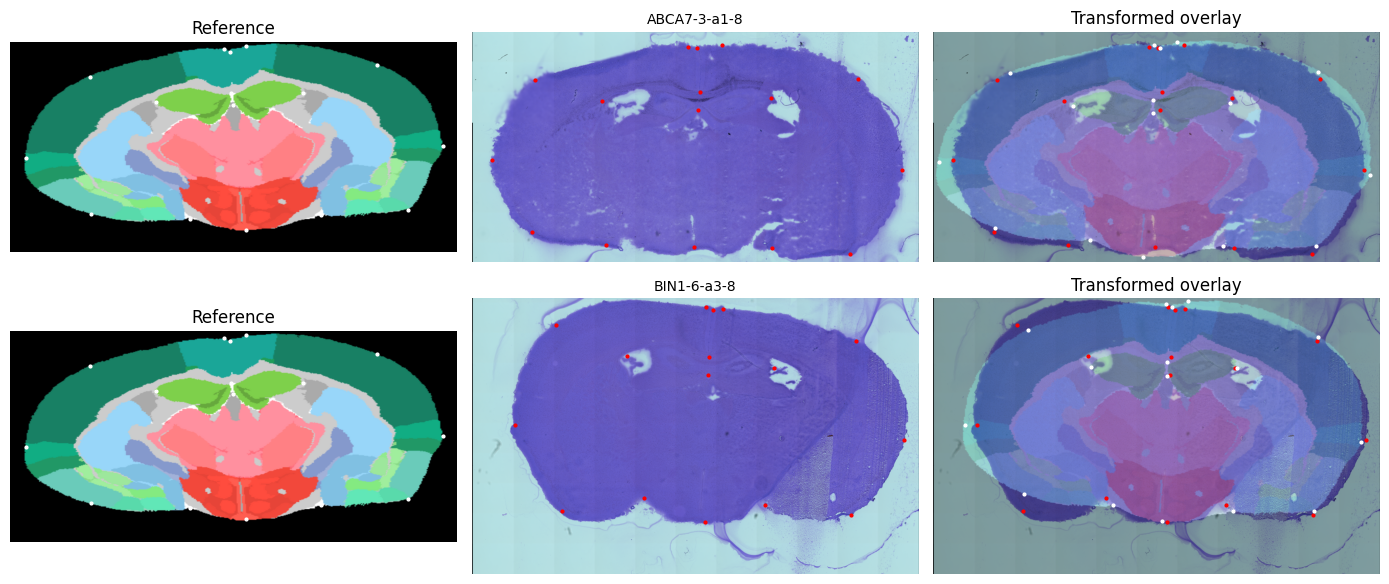

In [11]:
# STEP 3 - Display results of transformation and registration

import re
plt.figure(figsize=(14, nrow * 3))

for i, (sample, (reference_coords, query_coords), landmark_transformed, img, img_transformed) in enumerate(
    zip(samples, coord_sets, landmarks_transformed, query_images, images_transformed)
):
    # Panel 1: Reference image with landmarks
    plt.subplot(nrow, 3, 3 * i + 1)
    plt.title('Reference')
    plt.imshow(reference_image)
    plt.plot(
        reference_landmarks.iloc[0, :].filter(regex='V').values,
        reference_landmarks.iloc[1, :].filter(regex='V').values,
        'o', c="white", markersize=2
    )
    plt.axis('off')

    # Panel 2: Original Visium image (query) with its landmarks
    plt.subplot(nrow, 3, 3 * i + 2)
    plt.title(re.sub("_hires.png", "", sample), fontsize=10)
    plt.imshow(img)
    plt.plot(
        query_landmarks.iloc[2 * i, :].filter(regex='V').values,
        query_landmarks.iloc[2 * i + 1, :].filter(regex='V').values,
        'o', c="red", markersize=2
    )
    plt.axis('off')

    # Panel 3: Overlay of Visium + Transformed Reference + Landmarks
    plt.subplot(nrow, 3, 3 * i + 3)
    plt.title('Transformed overlay')
    plt.imshow(img)  # base Visium image
    plt.imshow(img_transformed, alpha=0.3)  # overlay transformed reference image
    plt.plot(
        query_landmarks.iloc[2 * i, :].filter(regex='V').values,
        query_landmarks.iloc[2 * i + 1, :].filter(regex='V').values,
        'o', c="red", markersize=2
    )
    plt.plot(
        pd.DataFrame(landmark_transformed).iloc[:, 0],
        pd.DataFrame(landmark_transformed).iloc[:, 1],
        'o', c="white", markersize=2
    )
    plt.axis('off')

# Save full figure
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'Spatial_Registration_ABCA7-3-a1-8_BIN1-6-a3-8.pdf'), dpi=400) # Change the name!!!!!! 


In [23]:
# STEP 4 - Link each spot to an annotation region

# Save transformed reference images (used as region masks)
for name, image in zip(samples, images_transformed):
    im_pil = Image.fromarray(image)
    im_pil.save(os.path.join(out_dir, f"{name}_hires_region.png"))

# Load color scheme
color_scheme = pd.read_csv(os.path.join(ref_dir, 'Color_Scheme_List.csv'))

# Load spot coordinates once
spots_coords = pd.read_csv(os.path.join(r_tab_dir, 'spots_coords_hi_res.csv'))

# Fix coordinate convention from R export
spots_coords[['imagerow', 'imagecol']] = spots_coords[['imagecol', 'imagerow']]

# Convert to int
spots_coords['imagerow'] = spots_coords['imagerow'].round().astype(int)
spots_coords['imagecol'] = spots_coords['imagecol'].round().astype(int)
spots_coords['region'] = "root"

# For each image, identify the region at each spot
for idx, sample in enumerate(samples):
    im = images_transformed[idx]
    mask = spots_coords['slice'] == sample

    for i in spots_coords[mask].index:
        row = spots_coords.at[i, 'imagerow']
        col = spots_coords.at[i, 'imagecol']
        height, width = im.shape[:2]

        if 0 <= row < height and 0 <= col < width:
            color = im[row, col]

            if not np.array_equal(color, [0, 0, 0]):
                match = color_scheme[
                    (color_scheme['R'] == color[0]) &
                    (color_scheme['G'] == color[1]) &
                    (color_scheme['B'] == color[2])
                ]

                if not match.empty:
                    spots_coords.at[i, 'region'] = match['LABEL'].values[0]

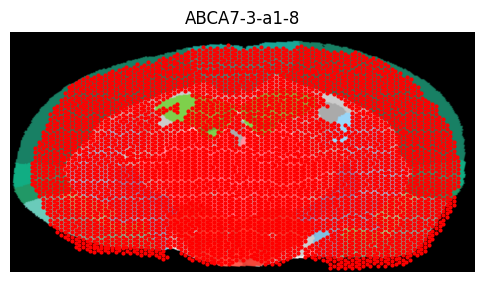

In [24]:
idx = 0
plt.figure(figsize=(6, 10))
plt.imshow(images_transformed[idx])
plt.plot(
    spots_coords.loc[spots_coords['slice'] == samples[idx], 'imagecol'],
    spots_coords.loc[spots_coords['slice'] == samples[idx], 'imagerow'],
    'ro',
    markersize=2
)
plt.title(samples[idx])
plt.axis("off")
plt.show()

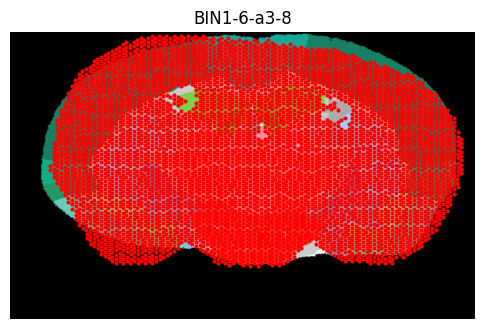

In [25]:
idx = 1
plt.figure(figsize=(6, 10))
plt.imshow(images_transformed[idx])
plt.plot(
    spots_coords.loc[spots_coords['slice'] == samples[idx], 'imagecol'],
    spots_coords.loc[spots_coords['slice'] == samples[idx], 'imagerow'],
    'ro',
    markersize=2
)
plt.title(samples[idx])
plt.axis("off")
plt.show()


In [26]:
spots_coords.to_csv(out_dir + "spots_coords_regions.csv") 